In [69]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [70]:
ruta = './Data/'
clientes = pd.read_excel(f'{ruta}Clientes.xlsx')
Detalle_ventas = pd.read_excel(f'{ruta}Detalle_ventas.xlsx')
Productos = pd.read_excel(f'{ruta}Productos.xlsx')
Ventas = pd.read_excel(f'{ruta}Ventas.xlsx')

In [71]:
clientes.head(2)

,id_cliente,nombre_cliente,email,ciudad,fecha_alta
0,1,Mariana Lopez,mariana.lopez@mail.com,Carlos Paz,2023-01-01
1,2,Nicolas Rojas,nicolas.rojas@mail.com,Carlos Paz,2023-01-02


In [100]:
Detalle_ventas.head(5)

,id_venta,id_producto,nombre_producto,cantidad,precio_unitario,importe
0,1,90,Toallas Húmedas x50,1,2902,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970
2,2,39,Helado Vainilla 1L,5,469,2345
3,2,70,Fernet 750ml,2,4061,8122
4,2,22,Medialunas de Manteca,1,2069,2069


In [73]:
Productos.head(2)

,id_producto,nombre_producto,categoria,precio_unitario
0,1,Coca Cola 1.5L,Alimentos,2347
1,3,Sprite 1.5L,Alimentos,4964


In [101]:
Ventas.head(5)

,id_venta,fecha,id_cliente,nombre_cliente,apellido_cliente,email,medio_pago
0,1,2024-06-19,62,Guadalupe,Romero,guadalupe.romero@mail.com,tarjeta
1,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr
2,3,2024-01-13,20,Tomas,Acosta,tomas.acosta@mail.com,tarjeta
3,4,2024-02-27,36,Martina,Molina,martina.molina@mail.com,transferencia
4,5,2024-06-11,56,Bruno,Diaz,bruno.diaz@mail.com,tarjeta


<Axes: xlabel='importe', ylabel='Density'>

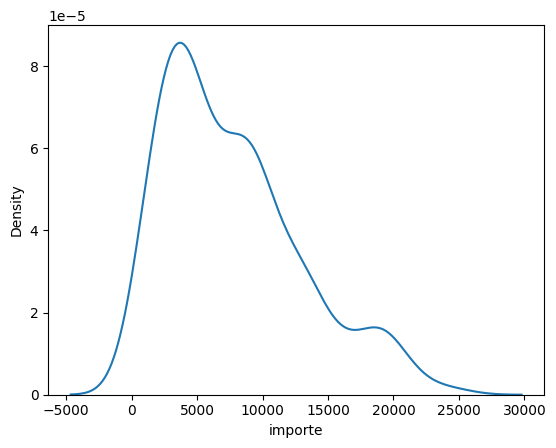

In [75]:
sns.kdeplot(Detalle_ventas['importe'])

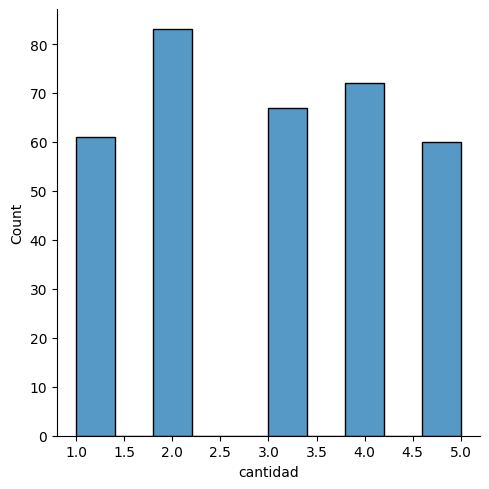

In [76]:
sns.displot(Detalle_ventas['cantidad'])

In [77]:
Cantidad = Ventas[['id_cliente', 'nombre_cliente']].groupby(by = 'id_cliente').count()
Cantidad = Cantidad.rename(columns={'nombre_cliente':'Numero_compras'})
Cantidad.describe()

,Numero_compras
count,67.000000
mean,1.791045
std,0.946081
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,5.000000


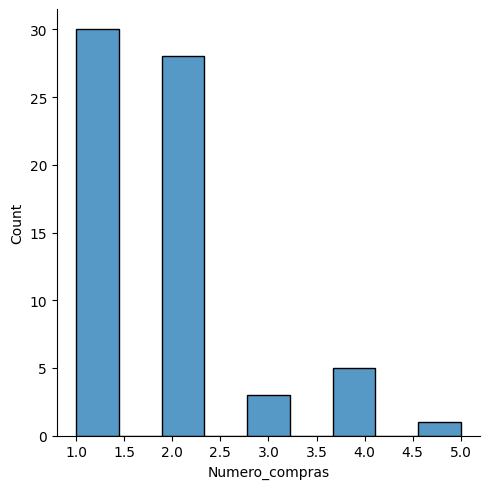

In [78]:
sns.displot(data = Cantidad['Numero_compras'])

In [79]:
Ventas_categorias = (Detalle_ventas.merge(
    Productos, on='id_producto'
))
Ventas_categorias

,id_venta,id_producto,nombre_producto_x,cantidad,precio_unitario_x,importe,nombre_producto_y,categoria,precio_unitario_y
0,1,90,Toallas Húmedas x50,1,2902,2902,Toallas Húmedas x50,Cuidado personal,2902
1,2,82,Aceitunas Negras 200g,5,2394,11970,Aceitunas Negras 200g,Alimentos,2394
2,2,39,Helado Vainilla 1L,5,469,2345,Helado Vainilla 1L,Alimentos,469
3,2,70,Fernet 750ml,2,4061,8122,Fernet 750ml,Licores,4061
4,2,22,Medialunas de Manteca,1,2069,2069,Medialunas de Manteca,Alimentos,2069
...,...,...,...,...,...,...,...,...,...
338,118,70,Fernet 750ml,2,4061,8122,Fernet 750ml,Licores,4061
339,118,93,Cepillo de Dientes,3,2142,6426,Cepillo de Dientes,Cuidado personal,2142
340,118,50,Azúcar 1kg,2,727,1454,Azúcar 1kg,Alimentos,727
341,119,45,Fideos Spaghetti 500g,5,745,3725,Fideos Spaghetti 500g,Alimentos,745


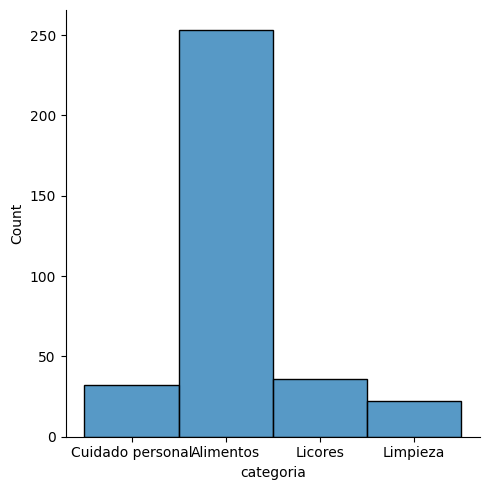

In [80]:
sns.displot(data = Ventas_categorias['categoria'])

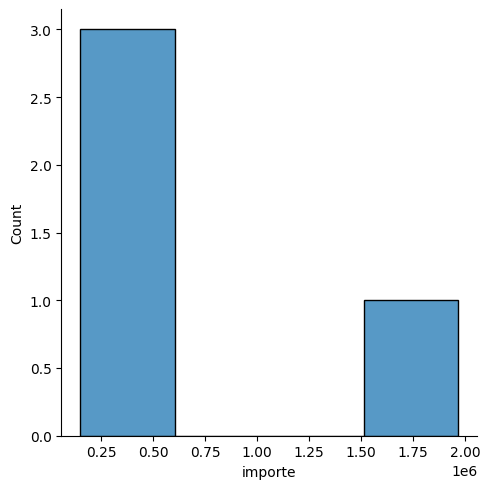

In [81]:
Suma_categoria = Ventas_categorias[['categoria', 'importe']].groupby('categoria').sum()
sns.displot(data = Suma_categoria['importe'])

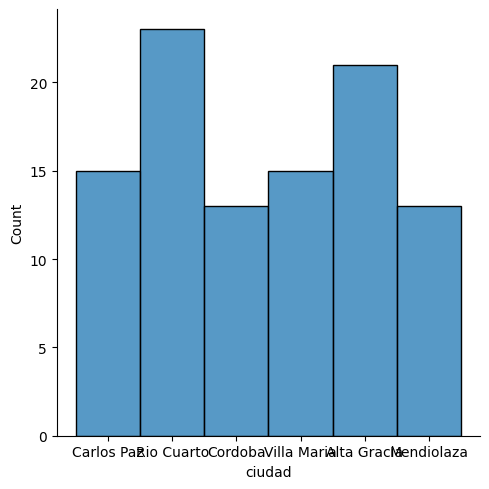

In [82]:
sns.displot(data = clientes['ciudad'])

In [83]:
Detalle_ventas.describe()

,id_venta,id_producto,cantidad,precio_unitario,importe
count,343.000000,343.000000,343.000000,343.000000,343.000000
mean,61.492711,49.139942,2.962099,2654.495627,7730.078717
std,34.835525,29.135461,1.366375,1308.694720,5265.543077
min,1.000000,1.000000,1.000000,272.000000,272.000000
25%,31.000000,23.000000,2.000000,1618.500000,3489.000000
50%,61.000000,47.000000,3.000000,2512.000000,6702.000000
75%,93.000000,76.000000,4.000000,3876.000000,10231.500000
max,120.000000,100.000000,5.000000,4982.000000,24865.000000


In [84]:
Ventas.describe()

,id_venta,fecha,id_cliente
count,120.000000,120,120.000000
mean,60.500000,2024-03-29 17:36:00,47.291667
min,1.000000,2024-01-02 00:00:00,1.000000
25%,30.750000,2024-02-11 06:00:00,24.500000
50%,60.500000,2024-03-25 00:00:00,48.500000
75%,90.250000,2024-05-19 06:00:00,67.500000
max,120.000000,2024-06-28 00:00:00,100.000000
std,34.785054,NaN,27.854181


In [85]:
Tabla_correlacion = (Ventas.merge(Detalle_ventas, how = 'inner', on = 'id_venta')
                     .merge(Productos, how = 'inner', on = 'id_producto')
                     .merge(clientes, how = 'inner', on = 'id_cliente')
                     .merge(Cantidad, on = 'id_cliente'))
Tabla_correlacion = Tabla_correlacion[['medio_pago', 'cantidad', 'importe', 'precio_unitario_x', 'categoria', 'ciudad', 'Numero_compras']]
Tabla_correlacion

,medio_pago,cantidad,importe,precio_unitario_x,categoria,ciudad,Numero_compras
0,tarjeta,1,2902,2902,Cuidado personal,Carlos Paz,2
1,qr,5,11970,2394,Alimentos,Rio Cuarto,4
2,qr,5,2345,469,Alimentos,Rio Cuarto,4
3,qr,2,8122,4061,Licores,Rio Cuarto,4
4,qr,1,2069,2069,Alimentos,Rio Cuarto,4
...,...,...,...,...,...,...,...
338,efectivo,2,8122,4061,Licores,Cordoba,2
339,efectivo,3,6426,2142,Cuidado personal,Cordoba,2
340,efectivo,2,1454,727,Alimentos,Cordoba,2
341,qr,5,3725,745,Alimentos,Rio Cuarto,2


In [86]:
diccionario = dict(enumerate(Tabla_correlacion.medio_pago.unique()))
Tabla_correlacion['medio_pago'] = Tabla_correlacion['medio_pago'].replace({valor: clave for clave, valor in diccionario.items()})
diccionario = dict(enumerate(Tabla_correlacion.categoria.unique()))
Tabla_correlacion['categoria'] = Tabla_correlacion['categoria'].replace({valor: clave for clave, valor in diccionario.items()})
diccionario = dict(enumerate(Tabla_correlacion.ciudad.unique()))
Tabla_correlacion['ciudad'] = Tabla_correlacion['ciudad'].replace({valor: clave for clave, valor in diccionario.items()})
Tabla_correlacion['Importe_medio'] = Tabla_correlacion['importe'] / Tabla_correlacion['cantidad']

C:\Users\Andres\AppData\Local\Temp\ipykernel_16704\3618668647.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Tabla_correlacion['medio_pago'] = Tabla_correlacion['medio_pago'].replace({valor: clave for clave, valor in diccionario.items()})
C:\Users\Andres\AppData\Local\Temp\ipykernel_16704\3618668647.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Tabla_correlacion['categoria'] = Tabla_correlacion['categoria'].replace({valor: clave for clave, valor in diccionario.items()})
C:\Users\Andres\AppData\Local\Temp\ipykernel_16704

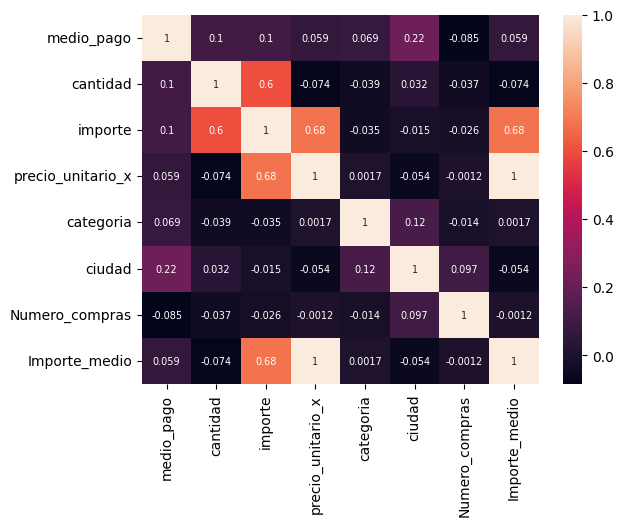

In [87]:
sns.heatmap(Tabla_correlacion.corr(), annot=True, annot_kws={"size": 7})
plt.show()

In [88]:
Ventas_historicas = (Ventas.merge(Detalle_ventas, how = 'inner', on = 'id_venta')
                     .merge(Productos, how = 'inner', on = 'id_producto'))
Ventas_historicas["fecha"] = pd.to_datetime(Ventas_historicas["fecha"])
Ventas_historicas['Importe_medio'] = Ventas_historicas['importe'] / Ventas_historicas['cantidad']
Ventas_historicas.head()

,id_venta,fecha,id_cliente,nombre_cliente,apellido_cliente,email,medio_pago,id_producto,nombre_producto_x,cantidad,precio_unitario_x,importe,nombre_producto_y,categoria,precio_unitario_y,Importe_medio
0,1,2024-06-19,62,Guadalupe,Romero,guadalupe.romero@mail.com,tarjeta,90,Toallas Húmedas x50,1,2902,2902,Toallas Húmedas x50,Cuidado personal,2902,2902.0
1,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,82,Aceitunas Negras 200g,5,2394,11970,Aceitunas Negras 200g,Alimentos,2394,2394.0
2,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,39,Helado Vainilla 1L,5,469,2345,Helado Vainilla 1L,Alimentos,469,469.0
3,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,70,Fernet 750ml,2,4061,8122,Fernet 750ml,Licores,4061,4061.0
4,2,2024-03-17,49,Olivia,Gomez,olivia.gomez@mail.com,qr,22,Medialunas de Manteca,1,2069,2069,Medialunas de Manteca,Alimentos,2069,2069.0


In [89]:
Ventas2 = Ventas_historicas[['fecha', 'Importe_medio']].groupby(by = ['fecha']).sum()
Ventas2.head(2)

,Importe_medio
fecha,
2024-01-02,6116.0
2024-01-04,469.0


<Axes: xlabel='fecha', ylabel='Importe_medio'>

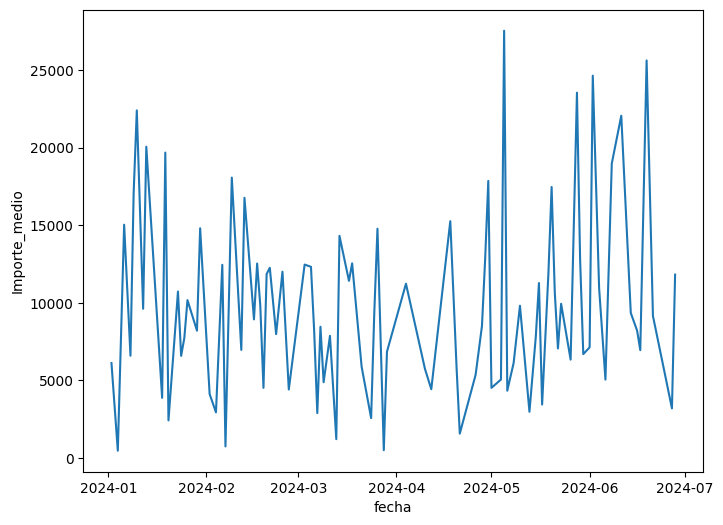

In [90]:
fig = plt.subplots(figsize=(8, 6))
sns.lineplot(x = 'fecha', y = 'Importe_medio', data = Ventas2)

In [91]:
Ventas2 = Ventas_historicas[['fecha', 'cantidad']].groupby(by = ['fecha']).sum()
Ventas2.head(2)

,cantidad
fecha,
2024-01-02,9
2024-01-04,4


<Axes: xlabel='fecha', ylabel='cantidad'>

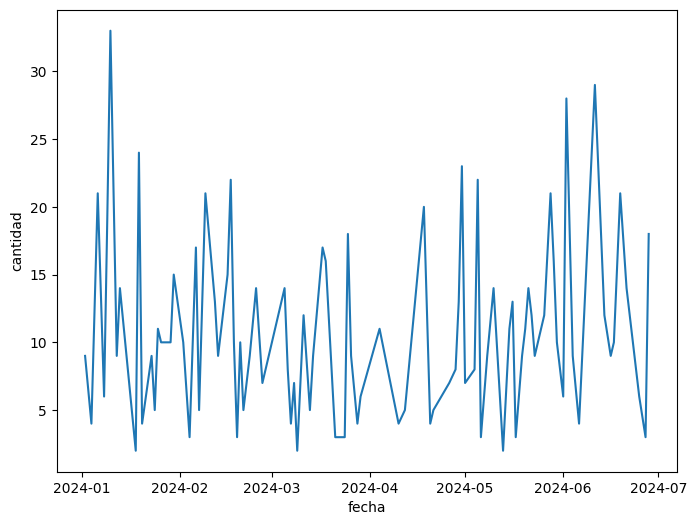

In [92]:
fig = plt.subplots(figsize=(8, 6))
sns.lineplot(x = 'fecha', y = 'cantidad', data = Ventas2)

In [93]:
Ventas2 = Ventas_historicas[['fecha', 'importe']].groupby(by = ['fecha']).sum()
Ventas2.head(2)

,importe
fecha,
2024-01-02,26294
2024-01-04,1876


<Axes: xlabel='categoria', ylabel='importe'>

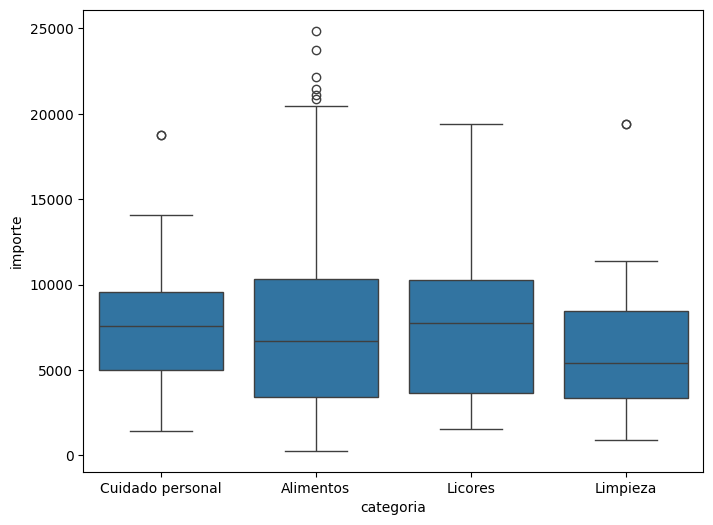

In [98]:
fig = plt.subplots(figsize=(8, 6))
sns.boxplot(x = Ventas_historicas['categoria'], y = Ventas_historicas['importe'])

<Axes: xlabel='fecha', ylabel='importe'>

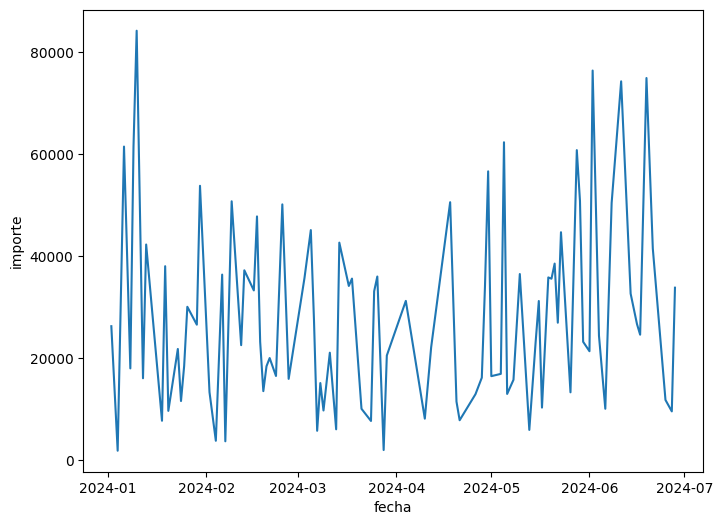

In [ ]:
fig = plt.subplots(figsize=(8, 6))
sns.lineplot(x = 'fecha', y = 'importe', data = Ventas2)

In [ ]:
Ventas2 = Ventas_historicas[['fecha', 'importe', 'categoria']].groupby(by = ['fecha', 'categoria']).sum()
Ventas2.head(2)

,,importe
fecha,categoria,
2024-01-02,Alimentos,26294
2024-01-04,Alimentos,1876


<Axes: xlabel='fecha', ylabel='importe'>

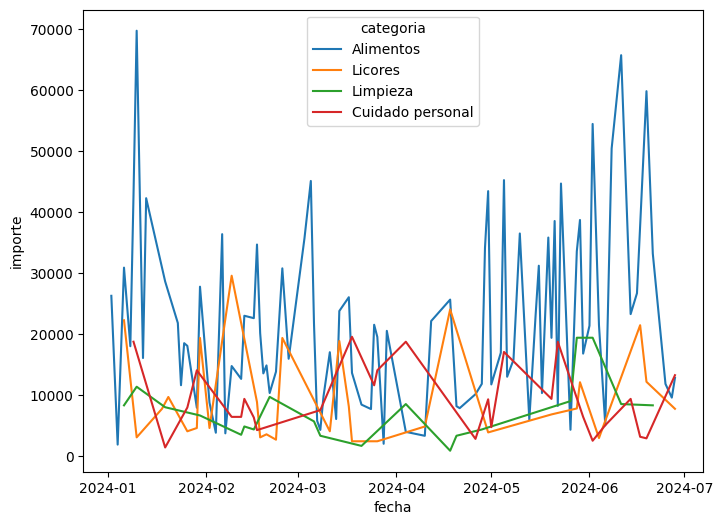

In [ ]:
fig = plt.subplots(figsize=(8, 6))
sns.lineplot(x = 'fecha', y = 'importe', data = Ventas2, hue = 'categoria')

In [ ]:
Ventas2 = Ventas_historicas[['fecha', 'importe', 'medio_pago']].groupby(by = ['fecha', 'medio_pago']).sum()
Ventas2.head(2)

,,importe
fecha,medio_pago,
2024-01-02,efectivo,26294
2024-01-04,qr,1876


<Axes: xlabel='fecha', ylabel='importe'>

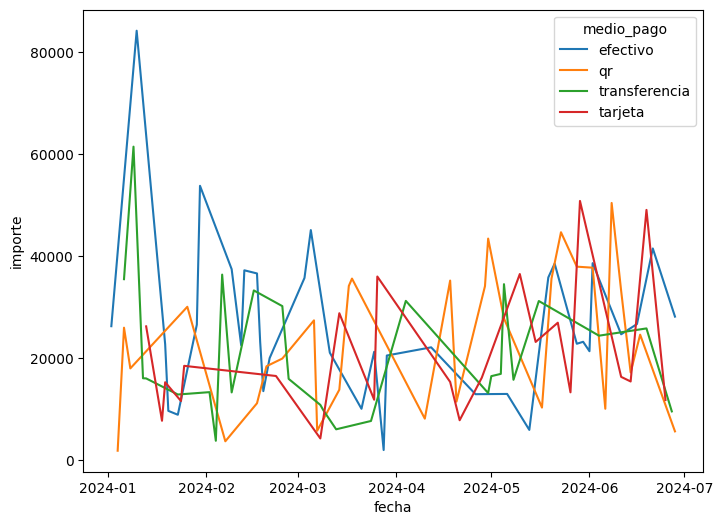

In [ ]:
fig = plt.subplots(figsize=(8, 6))
sns.lineplot(x = 'fecha', y = 'importe', data = Ventas2, hue = 'medio_pago')